## Libraries and data

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent)
print(path)
sys.path.insert(1, path)

import numpy as np
import pandas as pd
import skforecast

print(skforecast.__version__)

c:\Users\Joaquin\Documents\GitHub\skforecast
0.23.0


In [2]:
# Libraries
# ==============================================================================
import os
import pandas as pd
import torch
import time
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset
from skforecast.foundation import FoundationModel, ForecasterFoundation
from skforecast.model_selection import (
    TimeSeriesFold,
    backtesting_foundation,
    bayesian_search_foundation
)
from skforecast.plot import set_dark_theme

color = '\033[1m\033[38;5;208m' 
print(f"{color}torch version: {torch.__version__}")
print(f"  Cuda available : {torch.cuda.is_available()}")
print(f"  MPS available  : {torch.backends.mps.is_available()}")

torch version: 2.12.1+cu126
  Cuda available : True
  MPS available  : False


In [3]:
# Data download
# ==============================================================================
data = fetch_dataset(name='vic_electricity')

# Aggregating in 1H intervals
# ==============================================================================
# The Date column is eliminated so that it does not generate an error when aggregating.
data = data.drop(columns="Date")
data = (
    data
    .resample(rule="h", closed="left", label="right")
    .agg({
        "Demand": "mean",
        "Temperature": "mean",
        "Holiday": "mean",
    })
)
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Holiday
Time,,,
2011-12-31 14:00:00,4323.095350,21.225,1.0
2011-12-31 15:00:00,3963.264688,20.625,1.0
2011-12-31 16:00:00,3950.913495,20.325,1.0


In [4]:
# Split data into train-test
# ==============================================================================
data = data.loc['2012-01-01 00:00:00':'2014-12-30 23:00:00', :].copy()
end_train = '2014-11-30 23:59:00'
data_train = data.loc[: end_train, :].copy()
data_test  = data.loc[end_train:, :].copy()

print(f"Train dates: {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")


Train dates: 2012-01-01 00:00:00 --- 2014-11-30 23:00:00  (n=25560)
Test dates : 2014-12-01 00:00:00 --- 2014-12-30 23:00:00  (n=720)


In [5]:
data

,Demand,Temperature,Holiday
Time,,,
2012-01-01 00:00:00,4329.049863,27.000,1.0
2012-01-01 01:00:00,4685.820480,29.650,1.0
2012-01-01 02:00:00,5009.466997,31.650,1.0
2012-01-01 03:00:00,5270.116328,32.675,1.0
2012-01-01 04:00:00,5487.388289,32.300,1.0
...,...,...,...
2014-12-30 19:00:00,3307.042391,13.000,0.0
2014-12-30 20:00:00,3527.232855,12.100,0.0
2014-12-30 21:00:00,3846.439766,12.300,0.0


In [ ]:
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

estimator = FoundationModel(model_id="autogluon/chronos-2-small", context_length=150)
forecaster = ForecasterFoundation(estimator=estimator)


# Search space
def search_space(trial):
    search_space  = {
        'context_length' : trial.suggest_int('context_length', 100, 500),
    }
    
    return search_space

results, study = bayesian_search_foundation(
    forecaster=forecaster,
    series=data['Demand'],
    cv = cv,
    search_space = search_space,
    exog= data[['Temperature', 'Holiday']],
    metric = 'mean_absolute_error',
    n_trials= 5,

)

  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
results

,trial_number,levels,params,mean_absolute_error,context_length
0,4,[Demand],{'context_length': 388},168.273552,388
1,18,[Demand],{'context_length': 424},168.277777,424
2,12,[Demand],{'context_length': 416},168.393166,416
3,10,[Demand],{'context_length': 444},168.479531,444
4,11,[Demand],{'context_length': 448},168.643085,448
5,0,[Demand],{'context_length': 379},169.276201,379
6,13,[Demand],{'context_length': 384},169.328875,384
7,16,[Demand],{'context_length': 381},169.540340,381
8,19,[Demand],{'context_length': 437},169.585866,437
9,7,[Demand],{'context_length': 374},169.753827,374


In [ ]:
# Data
# ==============================================================================
data_multiseries = fetch_dataset(name="items_sales")
display(data_multiseries.head(3))

╭─────────────────────── items_sales ───────────────────────╮
│ Description:                                              │
│ Simulated time series for the sales of 3 different items. │
│                                                           │
│ Source:                                                   │
│ Simulated data.                                           │
│                                                           │
│ URL:                                                      │
│ https://raw.githubusercontent.com/skforecast/skforecast-  │
│ datasets/main/data/simulated_items_sales.csv              │
│                                                           │
│ Shape: 1097 rows x 3 columns                              │
╰───────────────────────────────────────────────────────────╯

,item_1,item_2,item_3
date,,,
2012-01-01,8.253175,21.047727,19.429739
2012-01-02,22.777826,26.578125,28.009863
2012-01-03,27.549099,31.751042,32.078922


In [ ]:
# Split data into train-test
# ==============================================================================
end_train = '2014-07-15 23:59:00'
data_multiseries_train = data_multiseries.loc[:end_train, :].copy()
data_multiseries_test  = data_multiseries.loc[end_train:, :].copy()

In [ ]:
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

estimator = FoundationModel(model_id="autogluon/chronos-2-small", context_length=150)
forecaster = ForecasterFoundation(estimator=estimator)


# Search space
def search_space(trial):
    search_space  = {
        'context_length' : trial.suggest_int('context_length', 100, 500),
    }
    
    return search_space

results, study = bayesian_search_foundation(
    forecaster=forecaster,
    series=data,
    cv = cv,
    search_space = search_space,
    metric = 'mean_absolute_error',
    n_trials= 5,
    suppress_warnings = True
)

  0%|          | 0/5 [00:00<?, ?it/s]

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\Documents\GitHub\skforecast\skforecast\utils\utils.py:3388          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\Documents\GitHub\skforecast\skforecast\utils\utils.py:3388          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\Documents\GitHub\skforecast\skforecast\utils\utils.py:3388          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\Documents\GitHub\skforecast\skforecast\utils\utils.py:3388          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\Documents\GitHub\skforecast\skforecast\utils\utils.py:3388          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\Documents\GitHub\skforecast\skforecast\utils\utils.py:3388          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

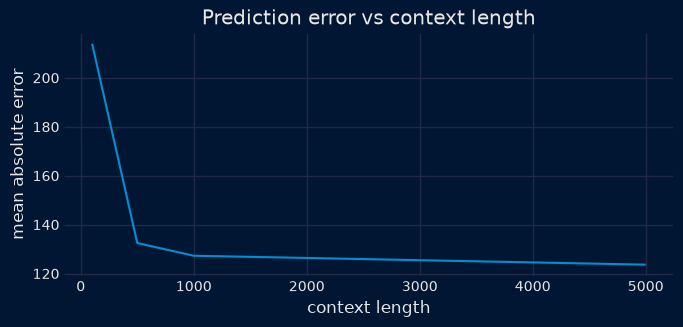

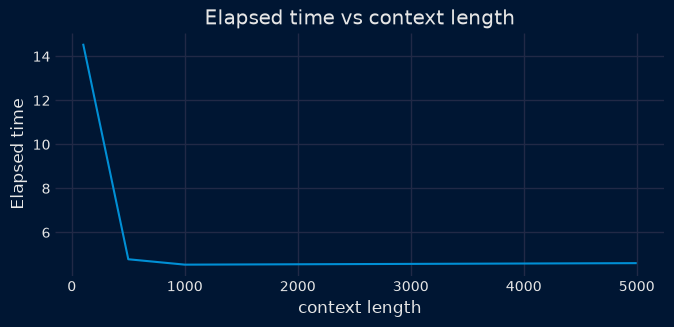

In [ ]:
# Plot results
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(7, 3))
results['metric'].plot(ax = ax)
ax.set_title("Prediction error vs context length")
ax.set_xlabel("context length")
ax.set_ylabel("mean absolute error")

fig, ax = plt.subplots(figsize=(7, 3))
results['elapsed_time'].plot(ax = ax)
ax.set_title("Elapsed time vs context length")
ax.set_xlabel("context length")
ax.set_ylabel("Elapsed time");